# Athabasca River 

## 1. Imports and user settings

In [1]:
from pathlib import Path
import json
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap, Normalize

# Put this notebook in the same folder as atha_topo.tif and atha.geojson.
ROOT = Path.cwd()
TOPO_TIF = ROOT / "atha_topo.tif"
REACH_GEOJSON = ROOT / "atha.geojson"
OUT_BASE = ROOT / "atha_definition_sketch_simple"

STATIONS = {
    "07DD011": (-111.524722, 58.396667),
    "07DD001": (-111.515000, 58.312500),
}

ELEVATION_RANGE = (210, 280)
COLORBAR_TICKS = [210, 225, 240, 255, 270, 280]

print("Topography exists:", TOPO_TIF.exists(), TOPO_TIF)
print("Reach GeoJSON exists:", REACH_GEOJSON.exists(), REACH_GEOJSON)

Topography exists: True d:\ice_river_flow\figs\atha_topo.tif
Reach GeoJSON exists: True d:\ice_river_flow\figs\atha.geojson


## 2. Style and data readers

In [8]:
def setup_style() -> None:
    """Use Times New Roman when available, without LaTeX."""

    if os.name == "nt":
        fonts_dir = Path(os.environ.get("WINDIR", r"C:\Windows")) / "Fonts"
        for name in ["times.ttf", "timesbd.ttf", "timesi.ttf", "timesbi.ttf"]:
            if (fonts_dir / name).exists():
                font_manager.fontManager.addfont(fonts_dir / name)

    mpl.rcParams.update({
        "text.usetex": False,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "Liberation Serif", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.unicode_minus": True,
    })


def soft_terrain_cmap() -> LinearSegmentedColormap:
    colors = ["#3d7da5", "#5ebca6", "#b1d88a", "#f4e7a6", "#ca9f73", "#8d6a5c"]
    return LinearSegmentedColormap.from_list("soft_terrain", colors, N=256)


def read_topography(path: Path):
    with rasterio.open(path) as src:
        dem = src.read(1, masked=True).astype(float)
        bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    return dem, bounds, extent


def read_reach_lines(path: Path) -> list[np.ndarray]:
    with path.open("r", encoding="utf-8") as f:
        geojson = json.load(f)

    def geometry_to_lines(geometry: dict) -> list[np.ndarray]:
        coords = geometry.get("coordinates", [])
        if geometry.get("type") == "LineString":
            return [np.asarray(coords, dtype=float)]
        if geometry.get("type") == "MultiLineString":
            return [np.asarray(line, dtype=float) for line in coords]
        return []

    if geojson.get("type") == "FeatureCollection":
        lines = []
        for feature in geojson.get("features", []):
            lines.extend(geometry_to_lines(feature.get("geometry", {})))
    elif geojson.get("type") == "Feature":
        lines = geometry_to_lines(geojson.get("geometry", {}))
    else:
        lines = geometry_to_lines(geojson)

    if not lines:
        raise ValueError(f"No LineString or MultiLineString found in {path}")
    return lines

## 3. Map annotations

In [21]:
def plot_reach(ax, lines: list[np.ndarray]) -> None:
    for line in lines:
        ax.plot(line[:, 0], line[:, 1], color="white", linewidth=3.05, zorder=3)
        ax.plot(line[:, 0], line[:, 1], color="#08306b", linewidth=1.28, zorder=4)


def add_stations(ax) -> None:
    offsets = {"07DD011": (6, 3), "07DD001": (6, 2)}
    label_box = {"boxstyle": "round,pad=0.12", "facecolor": "white", "edgecolor": "none", "alpha": 0.78}

    for label, (lon, lat) in STATIONS.items():
        ax.scatter(lon, lat, s=165, marker="*", facecolor="#b0007a", edgecolor="white", linewidth=0.5, zorder=6)
        ax.annotate(label, (lon, lat), xytext=offsets[label], textcoords="offset points",
                    ha="left", va="center", fontsize=11.5, weight="bold", bbox=label_box, zorder=7)

def add_scale_bar(ax, bounds, length_km: float = 5) -> None:
    lat = bounds.bottom + 0.035
    lon0 = bounds.left + 0.022
    lon1 = lon0 + length_km / (111.32 * np.cos(np.deg2rad(lat)))

    ax.plot([lon0, lon1], [lat, lat], color="white", linewidth=3.0, zorder=7)
    ax.plot([lon0, lon1], [lat, lat], color="black", linewidth=1.1, zorder=8)

    for lon in [lon0, lon1]:
        ax.plot([lon, lon], [lat - 0.0028, lat + 0.0028], color="white", linewidth=2.6, zorder=7)
        ax.plot([lon, lon], [lat - 0.0028, lat + 0.0028], color="black", linewidth=0.8, zorder=8)

    ax.text((lon0 + lon1) / 2, lat + 0.006, f"{length_km:g} km", ha="center", va="bottom",
            fontsize=10.5, bbox={"boxstyle": "round,pad=0.12", "facecolor": "white", "edgecolor": "none", "alpha": 0.75},
            zorder=8)

## 4. Draw and save the figure

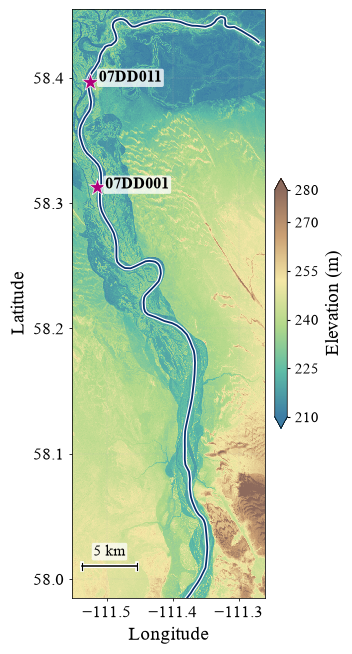

Created:
d:\ice_river_flow\figs\atha_definition_sketch_simple.png


In [22]:
def draw_map() -> None:
    setup_style()
    dem, bounds, extent = read_topography(TOPO_TIF)
    reach_lines = read_reach_lines(REACH_GEOJSON)

    fig, ax = plt.subplots(figsize=(3.55, 6.65))
    fig.subplots_adjust(left=0.16, right=0.80, bottom=0.075, top=0.96)

    image = ax.imshow(
        dem,
        extent=extent,
        origin="upper",
        cmap=soft_terrain_cmap(),
        norm=Normalize(*ELEVATION_RANGE),
        interpolation="nearest",
        zorder=0,
    )

    mean_lat = 0.5 * (bounds.bottom + bounds.top)
    ax.set_aspect(1 / np.cos(np.deg2rad(mean_lat)))

    plot_reach(ax, reach_lines)
    add_stations(ax)
    add_scale_bar(ax, bounds)

    ax.set_xlim(bounds.left + 0.008, bounds.right - 0.008)
    ax.set_ylim(bounds.bottom + 0.010, bounds.top - 0.004)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xticks([-111.5, -111.4, -111.3])
    ax.set_yticks([58.0, 58.1, 58.2, 58.3, 58.4])
    ax.tick_params(length=2.3, width=0.55)
    ax.grid(True, linestyle="--", linewidth=0.3, color="0.72", alpha=0.45)

    cbar = fig.colorbar(image, ax=ax, orientation="vertical", fraction=0.055, pad=0.045, extend="both")
    cbar.set_label("Elevation (m)")
    cbar.set_ticks(COLORBAR_TICKS)
    cbar.ax.tick_params(labelsize=11, length=2)
    cbar.outline.set_linewidth(0.55)

    for spine in ax.spines.values():
        spine.set_linewidth(0.55)

    fig.savefig(OUT_BASE.with_suffix(".png"), dpi=600, bbox_inches="tight")
    # fig.savefig(OUT_BASE.with_suffix(".pdf"), bbox_inches="tight")
    # fig.savefig(OUT_BASE.with_suffix(".tif"), dpi=600, bbox_inches="tight", pil_kwargs={"compression": "tiff_lzw"})
    plt.show()


draw_map()
print("Created:")
for suffix in [".png"]:
    print(OUT_BASE.with_suffix(suffix))